In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
data=pd.read_csv("housing.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
data.dropna(inplace=True)
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
X=data.drop(["median_house_value"] , axis=1)
Y=data["median_house_value"]
X,Y

(       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
 0        -122.23     37.88                41.0        880.0           129.0   
 1        -122.22     37.86                21.0       7099.0          1106.0   
 2        -122.24     37.85                52.0       1467.0           190.0   
 3        -122.25     37.85                52.0       1274.0           235.0   
 4        -122.25     37.85                52.0       1627.0           280.0   
 ...          ...       ...                 ...          ...             ...   
 20635    -121.09     39.48                25.0       1665.0           374.0   
 20636    -121.21     39.49                18.0        697.0           150.0   
 20637    -121.22     39.43                17.0       2254.0           485.0   
 20638    -121.32     39.43                18.0       1860.0           409.0   
 20639    -121.24     39.37                16.0       2785.0           616.0   
 
        population  households  median

In [6]:
#sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")
#plt.figure(figsize=(15,8))

In [7]:
from sklearn.model_selection import train_test_split
import random
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2)
random.seed(42)

#train data= both x_train and y_train
train_data=X_train.join(Y_train)
train_data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
12524,-121.48,38.56,44.0,1151.0,263.0,518.0,258.0,2.0089,INLAND,113600.0
19249,-122.74,38.46,9.0,2268.0,594.0,1311.0,585.0,2.6607,<1H OCEAN,91500.0
15344,-117.35,33.21,18.0,2971.0,606.0,2051.0,493.0,2.6750,NEAR OCEAN,117100.0
9886,-122.29,38.30,52.0,144.0,54.0,89.0,48.0,1.0096,NEAR BAY,162500.0
20385,-118.94,34.18,25.0,3502.0,508.0,1713.0,508.0,5.5181,<1H OCEAN,242100.0
...,...,...,...,...,...,...,...,...,...,...
14902,-117.06,32.61,23.0,1630.0,362.0,1267.0,418.0,2.5625,NEAR OCEAN,131100.0
18926,-122.17,38.08,7.0,18392.0,2782.0,8276.0,2742.0,6.4232,NEAR BAY,229200.0
17511,-121.92,37.34,42.0,2101.0,524.0,1212.0,526.0,3.6389,<1H OCEAN,239200.0
13280,-117.65,34.10,44.0,2808.0,585.0,1444.0,550.0,2.7159,INLAND,139300.0


In [8]:
train_data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7178
INLAND        5192
NEAR OCEAN    2120
NEAR BAY      1853
ISLAND           3
Name: count, dtype: int64

In [9]:
pd.get_dummies(train_data.ocean_proximity).astype(int)


,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12524,0,1,0,0,0
19249,1,0,0,0,0
15344,0,0,0,0,1
9886,0,0,0,1,0
20385,1,0,0,0,0
...,...,...,...,...,...
14902,0,0,0,0,1
18926,0,0,0,1,0
17511,1,0,0,0,0
13280,0,1,0,0,0


In [10]:
train_data=train_data.join(pd.get_dummies(train_data.ocean_proximity).astype(int)).drop(["ocean_proximity"], axis=1)


In [11]:
#train_data["bedroom_ratio"] = train_data["total_bedrooms"] / train_data["total_rooms"]
#train_data["rooms_per_household"] = train_data["total_rooms"] / train_data["households"]
#train_data["people_per_household"] = train_data["population"] / train_data["households"]

In [12]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12524,-121.48,38.56,44.0,1151.0,263.0,518.0,258.0,2.0089,113600.0,0,1,0,0,0
19249,-122.74,38.46,9.0,2268.0,594.0,1311.0,585.0,2.6607,91500.0,1,0,0,0,0
15344,-117.35,33.21,18.0,2971.0,606.0,2051.0,493.0,2.6750,117100.0,0,0,0,0,1
9886,-122.29,38.30,52.0,144.0,54.0,89.0,48.0,1.0096,162500.0,0,0,0,1,0
20385,-118.94,34.18,25.0,3502.0,508.0,1713.0,508.0,5.5181,242100.0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14902,-117.06,32.61,23.0,1630.0,362.0,1267.0,418.0,2.5625,131100.0,0,0,0,0,1
18926,-122.17,38.08,7.0,18392.0,2782.0,8276.0,2742.0,6.4232,229200.0,0,0,0,1,0
17511,-121.92,37.34,42.0,2101.0,524.0,1212.0,526.0,3.6389,239200.0,1,0,0,0,0
13280,-117.65,34.10,44.0,2808.0,585.0,1444.0,550.0,2.7159,139300.0,0,1,0,0,0


<Axes: >

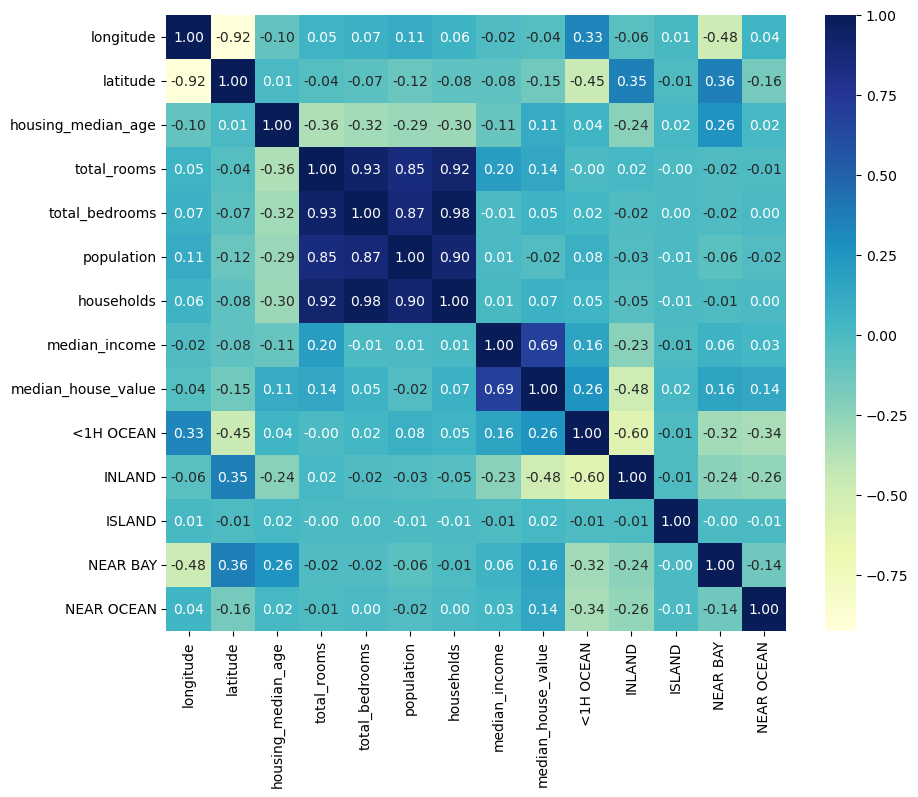

In [13]:
corr=train_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

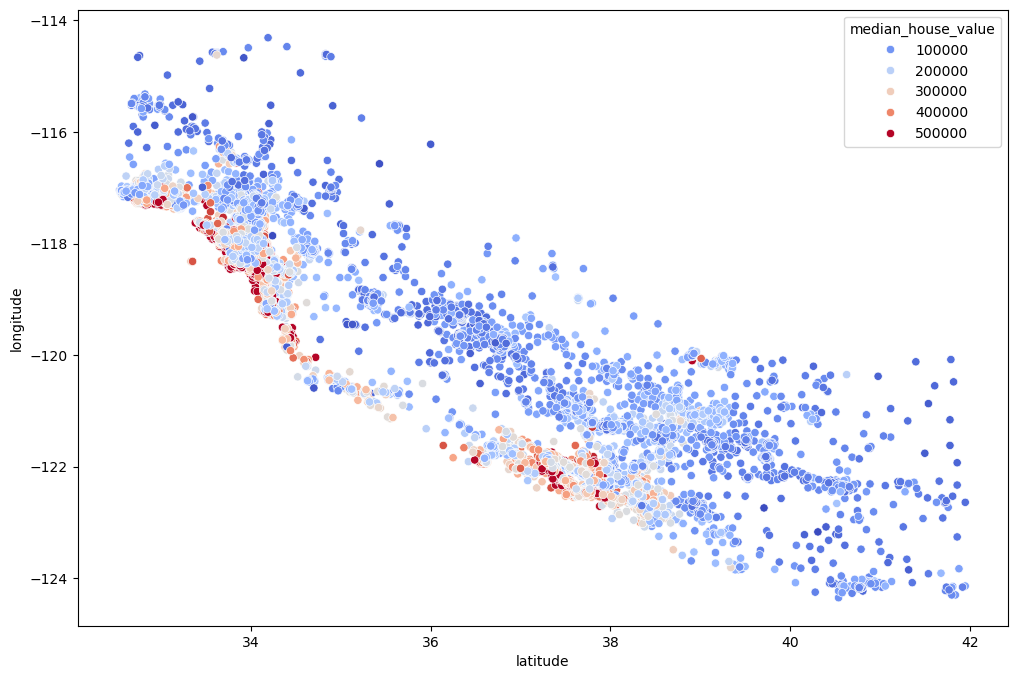

In [14]:
plt.figure(figsize=(12,8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

In [15]:

from sklearn.linear_model import LinearRegression

X_train, Y_train = train_data.drop(["median_house_value"],axis=1) , train_data["median_house_value"]
reg=LinearRegression()

#TRAINING THE DATA 
reg.fit(X_train, Y_train)


LinearRegression()

In [16]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12524,-121.48,38.56,44.0,1151.0,263.0,518.0,258.0,2.0089,0,1,0,0,0
19249,-122.74,38.46,9.0,2268.0,594.0,1311.0,585.0,2.6607,1,0,0,0,0
15344,-117.35,33.21,18.0,2971.0,606.0,2051.0,493.0,2.6750,0,0,0,0,1
9886,-122.29,38.30,52.0,144.0,54.0,89.0,48.0,1.0096,0,0,0,1,0
20385,-118.94,34.18,25.0,3502.0,508.0,1713.0,508.0,5.5181,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14902,-117.06,32.61,23.0,1630.0,362.0,1267.0,418.0,2.5625,0,0,0,0,1
18926,-122.17,38.08,7.0,18392.0,2782.0,8276.0,2742.0,6.4232,0,0,0,1,0
17511,-121.92,37.34,42.0,2101.0,524.0,1212.0,526.0,3.6389,1,0,0,0,0
13280,-117.65,34.10,44.0,2808.0,585.0,1444.0,550.0,2.7159,0,1,0,0,0


In [17]:
# WE HAVE DONE FOR TRAIN DATA DO THE SAME FOR TEST DATA FROM COPY PASTE FROM ABOVE CELLS

test_data=X_test.join(Y_test)
pd.get_dummies(test_data.ocean_proximity).astype(int)
test_data=test_data.join(pd.get_dummies(test_data.ocean_proximity).astype(int)).drop(["ocean_proximity"], axis=1)
test_data = test_data.reindex(columns=train_data.columns, fill_value=0)

X_test, Y_test = test_data.drop(["median_house_value"],axis=1) , test_data["median_house_value"]
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
8406,-118.36,33.94,33.0,939.0,284.0,1309.0,250.0,3.4063,152300.0,1,0,0,0,0
176,-122.24,37.80,52.0,1586.0,398.0,1006.0,335.0,2.1348,140600.0,0,0,0,1,0
14346,-117.19,32.75,33.0,1115.0,316.0,583.0,269.0,2.5882,258300.0,0,0,0,0,1
15534,-117.11,33.14,10.0,3208.0,636.0,1395.0,582.0,3.4455,190500.0,1,0,0,0,0
8287,-118.15,33.77,41.0,3448.0,896.0,1621.0,838.0,4.5000,339800.0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10729,-117.87,33.60,20.0,3212.0,572.0,1064.0,526.0,6.6155,500001.0,1,0,0,0,0
16324,-121.33,37.98,9.0,2370.0,424.0,1129.0,386.0,5.1430,176500.0,0,1,0,0,0
11542,-118.02,33.75,26.0,2989.0,479.0,1596.0,475.0,5.7157,231200.0,1,0,0,0,0
3620,-118.45,34.25,21.0,2143.0,565.0,1803.0,497.0,3.9833,162500.0,1,0,0,0,0


In [18]:
X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
8406,-118.36,33.94,33.0,939.0,284.0,1309.0,250.0,3.4063,1,0,0,0,0
176,-122.24,37.80,52.0,1586.0,398.0,1006.0,335.0,2.1348,0,0,0,1,0
14346,-117.19,32.75,33.0,1115.0,316.0,583.0,269.0,2.5882,0,0,0,0,1
15534,-117.11,33.14,10.0,3208.0,636.0,1395.0,582.0,3.4455,1,0,0,0,0
8287,-118.15,33.77,41.0,3448.0,896.0,1621.0,838.0,4.5000,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10729,-117.87,33.60,20.0,3212.0,572.0,1064.0,526.0,6.6155,1,0,0,0,0
16324,-121.33,37.98,9.0,2370.0,424.0,1129.0,386.0,5.1430,0,1,0,0,0
11542,-118.02,33.75,26.0,2989.0,479.0,1596.0,475.0,5.7157,1,0,0,0,0
3620,-118.45,34.25,21.0,2143.0,565.0,1803.0,497.0,3.9833,1,0,0,0,0


In [19]:
#from sklearn.metrics import accracy_score
#reg.score(X_test, Y_test)

In [20]:
reg.predict(X_train)

array([104067.61381178, 180662.4426415 , 147245.38268237, ...,
       255113.85580703, 144127.6850044 , 379455.3295875 ])

In [21]:

reg.score(X_test, Y_test)

0.6461587053666256

In [22]:
#TRY WITH OTHER REGRESSORSSS
from sklearn.ensemble import RandomForestRegressor
Forest = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42)
Forest.fit(X_train, Y_train)


RandomForestRegressor(max_depth=20, min_samples_split=5, n_estimators=200,
                      random_state=42)

In [23]:
prediction=Forest.predict(X_train)
prediction

array([102442.8391943 , 120668.84603175, 136779.96735807, ...,
       246447.62096086, 129736.42828838, 417239.28449603])

In [24]:
Forest.score(X_test,Y_test)

0.8247200947584645

In [25]:
from sklearn.metrics import mean_squared_error
preds = Forest.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, preds))
print(f"RMSE: ${rmse:,.0f}")
print(f"R² Score: {Forest.score(X_test, Y_test):.4f}")

RMSE: $47,739
R² Score: 0.8247


In [26]:
import joblib


joblib.dump(Forest, "housing_price_model.pkl")
joblib.dump(X_train.columns, "feature_columns.pkl")

['feature_columns.pkl']

In [27]:
import os 
os.getcwd()

'C:\\Users\\prave'